🛒 Notebook 03: Product Category & Basket Size Analysis

Questo notebook esplora l'assortimento prodotti e la composizione dei carrelli d'acquisto:

1. Performance economica per Categoria e Sotto-Categoria.

1. Identificazione dei prodotti Top e Bottom per volume e fatturato.

1. Analisi della dimensione media del carrello (Basket Size) per ogni Order ID.

1. Analisi delle sotto-categorie acquistate frequentemente insieme nello stesso ordine (Cross-Selling).

### 1. Importazione Librerie e Caricamento Dati

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

CLEANED_DATA_PATH = '../data/superstore_cleaned.csv'
df = pd.read_csv(CLEANED_DATA_PATH)

print(f"Dataset caricato: {df.shape[0]} righe x {df.shape[1]} colonne.")

Dataset caricato: 9800 righe x 25 colonne.


### 2. Performance per Categoria e Sotto-Categoria

,Category,Sub-Category,Total_Sales,Avg_Order_Value,Total_Orders,Sales_Share_%
1,Furniture,Chairs,322822.7310,531.833165,607,14.27
3,Furniture,Tables,202810.6280,645.893720,314,8.97
0,Furniture,Bookcases,113813.1987,503.598224,226,5.03
2,Furniture,Furnishings,89212.0180,95.823865,931,3.94
11,Office Supplies,Storage,219343.3920,263.633885,832,9.70
6,Office Supplies,Binders,200028.7850,134.067550,1492,8.84
4,Office Supplies,Appliances,104618.4030,227.926804,459,4.63
10,Office Supplies,Paper,76828.3040,57.420257,1338,3.40
12,Office Supplies,Supplies,46420.3080,252.284283,184,2.05
5,Office Supplies,Art,26705.4100,34.019631,785,1.18


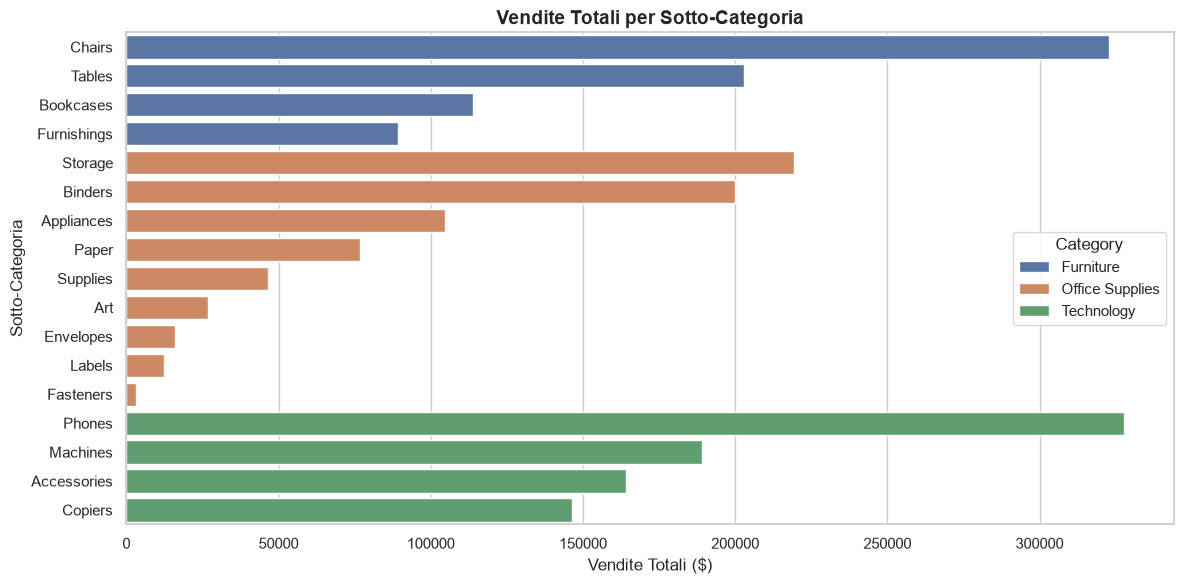

In [2]:
# Aggregazione per Category e Sub-Category
cat_summary = (
    df.groupby(['Category', 'Sub-Category'])['Sales']
    .agg(
        Total_Sales=('sum'),
        Avg_Order_Value=('mean'),
        Total_Orders=('count')
    )
    .reset_index()
    .sort_values(by=['Category', 'Total_Sales'], ascending=[True, False])
)

# Calcolo quota percentuale di vendita per sotto-categoria
total_sales_all = df['Sales'].sum()
cat_summary['Sales_Share_%'] = (cat_summary['Total_Sales'] / total_sales_all * 100).round(2)

display(cat_summary)

# Visualizzazione grafico a barre delle Vendite per Sotto-Categoria
plt.figure(figsize=(12, 6))
sns.barplot(data=cat_summary, x='Total_Sales', y='Sub-Category', hue='Category', dodge=False)
plt.title("Vendite Totali per Sotto-Categoria", fontsize=14, fontweight='bold')
plt.xlabel("Vendite Totali ($)")
plt.ylabel("Sotto-Categoria")
plt.tight_layout()
plt.show()

### 3. Top e Bottom Products (Analisi di Prodotto)

In [3]:
# Top 10 Prodotti per Fatturato
top_products = (
    df.groupby('Product Name')['Sales']
    .sum()
    .nlargest(10)
    .reset_index()
)

print("--- TOP 10 PRODOTTI PER FATTURATO ---")
display(top_products)

# Bottom 10 Prodotti per Fatturato
bottom_products = (
    df.groupby('Product Name')['Sales']
    .sum()
    .nsmallest(10)
    .reset_index()
)

print("\n--- BOTTOM 10 PRODOTTI PER FATTURATO ---")
display(bottom_products)

--- TOP 10 PRODOTTI PER FATTURATO ---


,Product Name,Sales
0,Canon imageCLASS 2200 Advanced Copier,61599.824
1,Fellowes PB500 Electric Punch Plastic Comb Bin...,27453.384
2,Cisco TelePresence System EX90 Videoconferenci...,22638.480
3,HON 5400 Series Task Chairs for Big and Tall,21870.576
4,GBC DocuBind TL300 Electric Binding System,19823.479
5,GBC Ibimaster 500 Manual ProClick Binding System,19024.500
6,Hewlett Packard LaserJet 3310 Copier,18839.686
7,HP Designjet T520 Inkjet Large Format Printer ...,18374.895
8,GBC DocuBind P400 Electric Binding System,17965.068
9,High Speed Automatic Electric Letter Opener,17030.312



--- BOTTOM 10 PRODOTTI PER FATTURATO ---


,Product Name,Sales
0,Eureka Disposable Bags for Sanitaire Vibra Gro...,1.624
1,Avery 5,5.760
2,Xerox 20,6.480
3,Grip Seal Envelopes,7.072
4,Acme Serrated Blade Letter Opener,7.632
5,Avery Hi-Liter Pen Style Six-Color Fluorescent...,7.700
6,Avery Hi-Liter Comfort Grip Fluorescent Highli...,7.800
7,Xerox 1989,7.968
8,4009 Highlighters,8.040
9,Stockwell Gold Paper Clips,8.096


### 4. Analisi del Basket Size (Dimensione del Carrello)

In [4]:
# Calcolo numero di articoli e categorie distinte per ogni Order ID
basket_analysis = df.groupby('Order ID').agg(
    Items_Count=('Product ID', 'count'),
    Unique_Categories=('Category', 'nunique'),
    Unique_SubCategories=('Sub-Category', 'nunique'),
    Total_Basket_Value=('Sales', 'sum')
).reset_index()

print("--- DISTRIBUZIONE DIMENSIONE CARRELLO ---")
display(basket_analysis[['Items_Count', 'Unique_Categories', 'Total_Basket_Value']].describe().round(2))

# Percentuale di ordini multi-articolo vs mono-articolo
multi_item_pct = (basket_analysis['Items_Count'] > 1).mean() * 100
print(f"\nPercentuale di ordini con più di un articolo: {multi_item_pct:.2f}%")

--- DISTRIBUZIONE DIMENSIONE CARRELLO ---


,Items_Count,Unique_Categories,Total_Basket_Value
count,4922.00,4922.00,4922.00
mean,1.99,1.41,459.48
std,1.41,0.61,958.67
min,1.00,1.00,0.56
25%,1.00,1.00,37.27
50%,1.00,1.00,151.88
75%,2.00,2.00,513.51
max,14.00,3.00,23661.23



Percentuale di ordini con più di un articolo: 49.23%


### 5. Analisi degli Acquisti Incrociati (Cross-Selling / Product Co-occurrence)

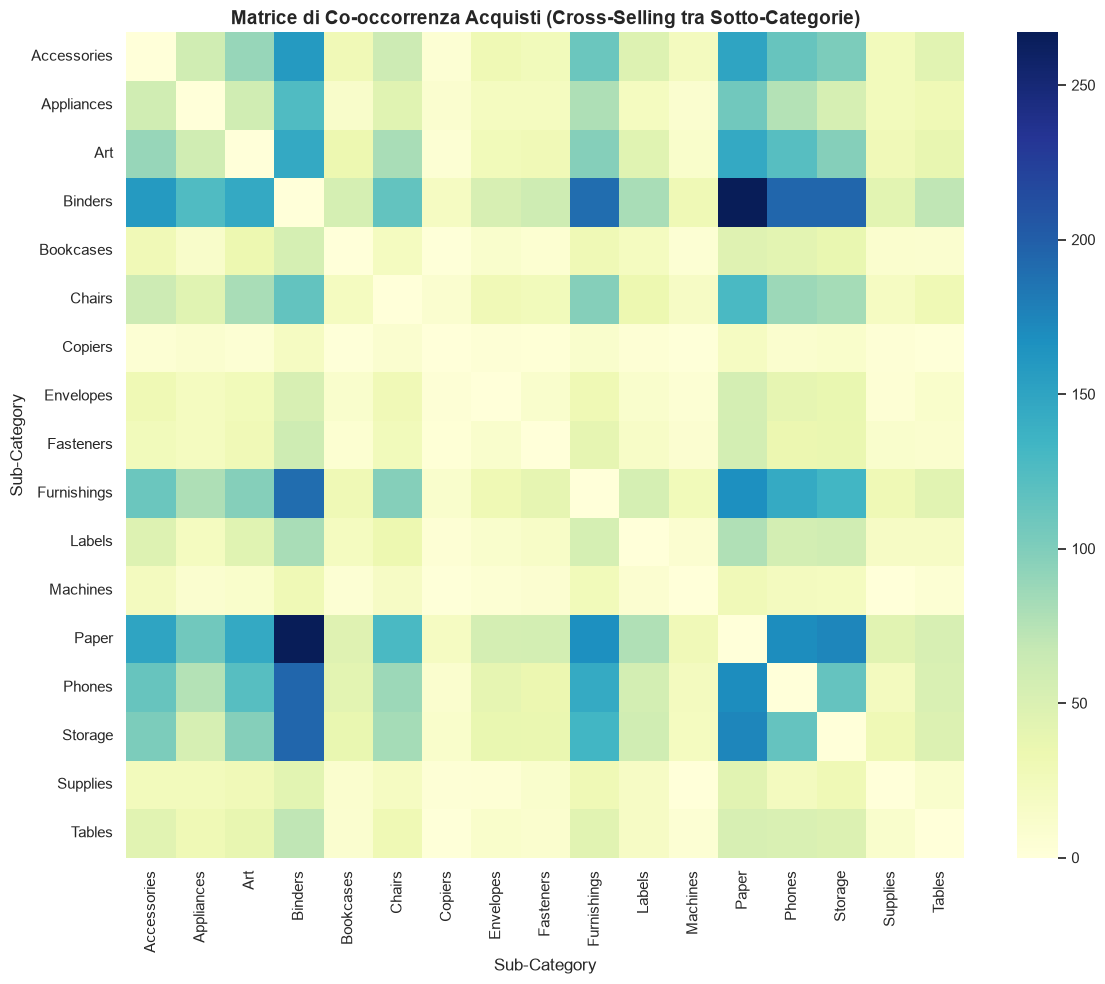

In [6]:
# Creiamo una tabella binaria per identificare quali Sub-Category sono presenti in ciascun Order ID
basket_matrix = (
    df.groupby(['Order ID', 'Sub-Category'])['Product ID']
    .count()
    .unstack()
    .fillna(0)
)

# Convertiamo in booleano (1 se presente nell'ordine, 0 altrimenti)
basket_matrix = (basket_matrix > 0).astype(int)

# Calcoliamo la matrice di co-occorrenza (quante volte due Sotto-Categorie appaiono insieme)
co_matrix = basket_matrix.T.dot(basket_matrix)

# Azzeriamo la diagonale principale per concentrarci sugli accoppiamenti
co_matrix = co_matrix.mask(np.eye(len(co_matrix), dtype=bool), 0)

# Heatmap visiva delle co-occorrenze principali
plt.figure(figsize=(12, 10))
sns.heatmap(co_matrix, cmap='YlGnBu', annot=False)
plt.title("Matrice di Co-occorrenza Acquisti (Cross-Selling tra Sotto-Categorie)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()